shape of s_data_all = (26, 780)
Sample/ROI length: 2.463977


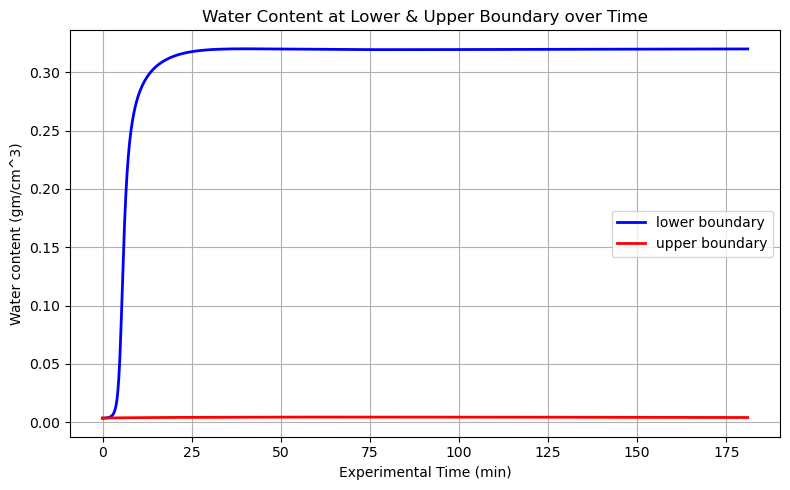

sample size: cms 2.463977
test Time:  181.0


In [2]:
import tensorflow as tf
import numpy as np
from tqdm.notebook import tqdm
import time
import os
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp


PINN_result_dir = "/data/Sunav/Final_Deep_Ens_grid_search/LS_DE_scaled/best"             # Change this to correct directory as required
exp_data_dir = "/data/Sunav/Code_Diffusion_PINN/data/"                              # Change this to correct directory as required

save_dir = os.getcwd()

# Load experimental data
s_data_all = np.load(os.path.join(exp_data_dir, "LS_log_profiles.npy"))* -5.44366
time_data_all = np.load(os.path.join(exp_data_dir, "LS_difference_times.npy"))


# Create PINN time grid (1000 equally spaced points between 0 and 1)
num_pinn_times = 1000
pinn_times = np.linspace(0, 1, num_pinn_times)

# Define spatial coordinates
pixel_size = 31.63  # micrometers
print("shape of s_data_all =", s_data_all.shape)
x_data = np.arange(s_data_all.shape[1]) * pixel_size / 10000  # in millimeters
x_pinn = np.linspace(0, 1, num_pinn_times) * x_data[-1]

time_max = np.max(time_data_all)

sample_length = np.max(x_data)
print("Sample/ROI length:", sample_length)

total_time = time_max

diffusion_scaling_factor = sample_length**2 / (4 * total_time)

# Load PINN prediction data
u_hat_mean = np.load(os.path.join(PINN_result_dir, 'u_hat_mean_750.npy'))

# Step 1: Get saturation at x = 0  and x=L for all time points
u_lower_boundary = u_hat_mean[:, 0]  # shape = (num_pinn_times,)
u_upper_boundary = u_hat_mean[:, -1]  # shape = (num_pinn_times,)

# Step 2: Convert normalized time to actual time in minutes
actual_times = pinn_times * total_time  # already normalized, scale to actual

# Step 3: Plot Upper & Lower Boundary Saturation - PINN obtained
plt.figure(figsize=(8, 5))
plt.plot(actual_times, u_lower_boundary, 'b-', lw=2, label= 'lower boundary')
plt.plot(actual_times, u_upper_boundary, 'r-', lw=2, label= 'upper boundary')
plt.xlabel('Experimental Time (min)')
plt.ylabel('Water content (gm/cm^3)')
plt.title('Water Content at Lower & Upper Boundary over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print("sample size: cms",sample_length)
print("test Time: ", total_time)

# Create interpolation function based on PINN prediction at x=0 & x=L
interp_lbc = interp1d(actual_times, u_lower_boundary, kind='cubic', fill_value="extrapolate")
interp_ubc = interp1d(actual_times, u_upper_boundary, kind='cubic', fill_value="extrapolate")

dt = 2.4e-3
Nt = int(np.round(total_time / dt)) + 1
simulation_times = np.linspace(0, total_time, Nt)

# Interpolate to FDM time grid
lbc_for_fdm = interp_lbc(simulation_times)  # Shape: (Nt,)
ubc_for_fdm = interp_ubc(simulation_times)  # Shape: (Nt,)

### Run FDM on X-ray experiment using determined diffusivity relationship and PINN extracted BCs.

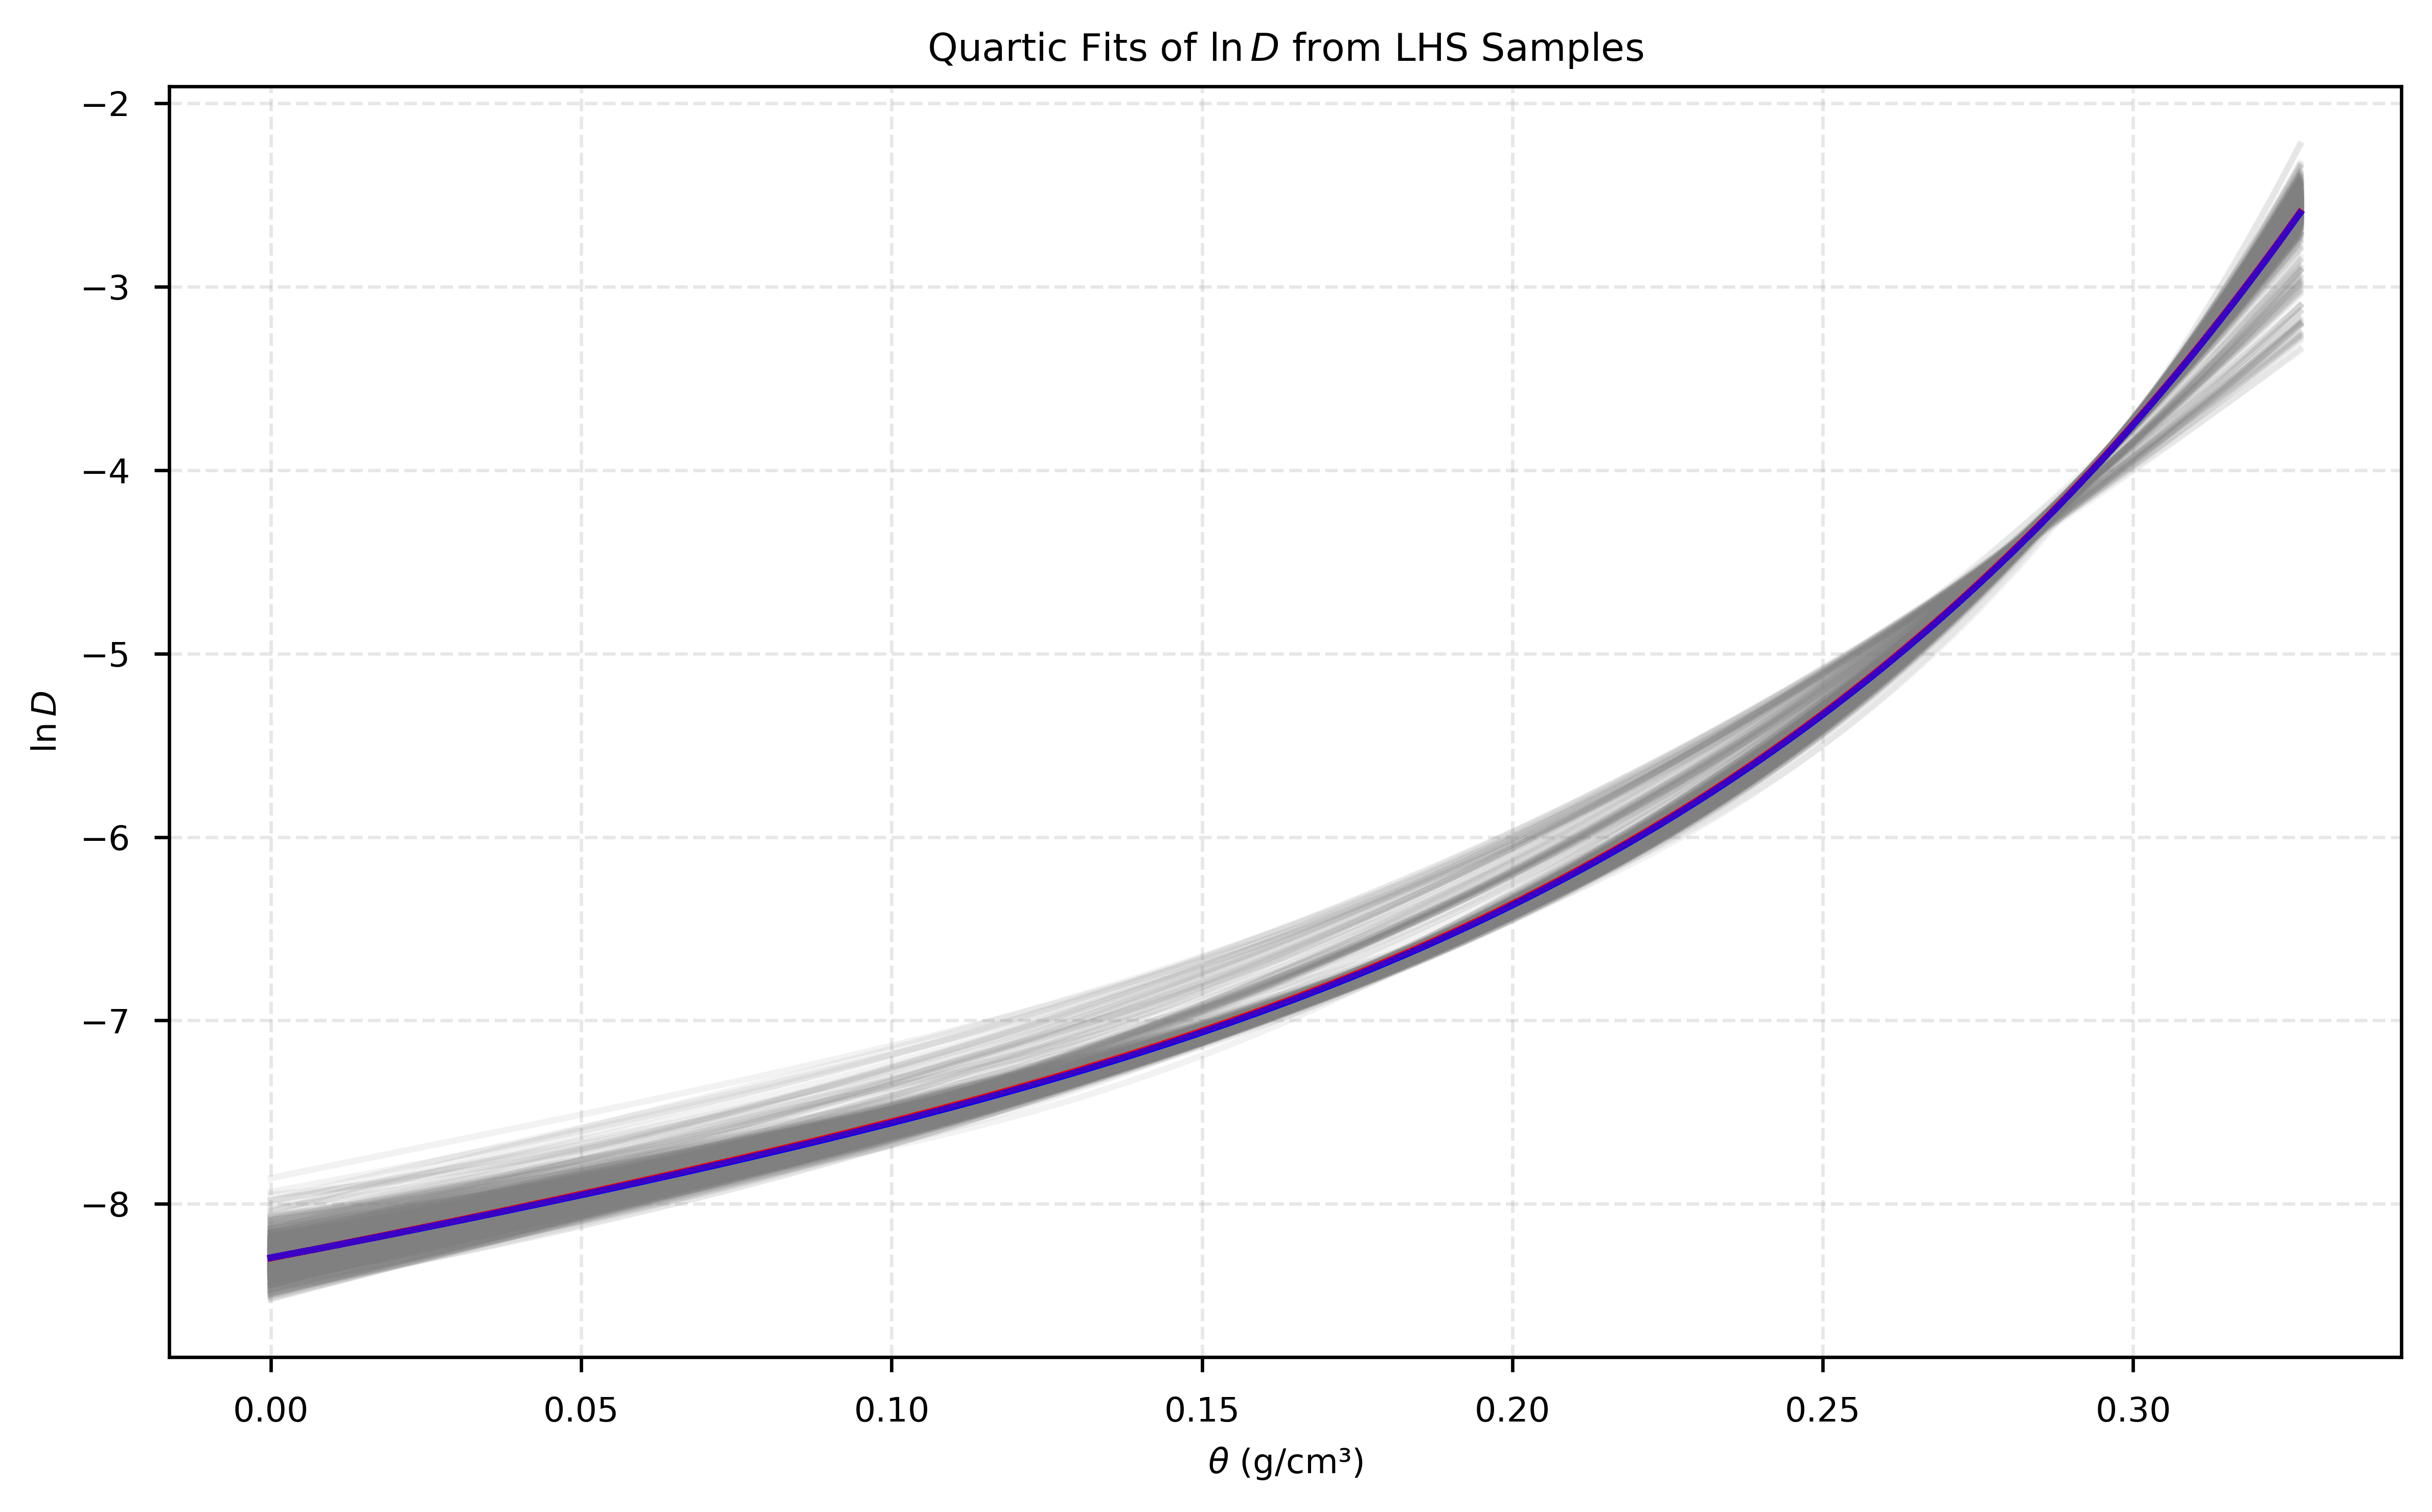

Mean Quartic Coefficients for ln(D) vs. θ from average of 750 fits evaluated on fixed grid:\
coefficient form is: ln(D) = a·θ⁴ + b·θ³ + c·θ² + d·θ + e\
Coefficient a = 319.377527\
Coefficient b = -28.106100\
Coefficient c = 8.616007\
Coefficient d = 6.462060\
Coefficient e = -8.293850

In [3]:

# Parameters
L  = sample_length      # length of the domain
Nx = 1001      # number of spatial steps
dx = L / (Nx - 1) 
dt = 2.4e-3
Nt = int(np.round(total_time / dt)) + 1
D0 = np.exp(-8.293850)  # initial diffusivity
a = 319.377527
b = -28.106100
c = 8.616007
d = 6.462060

# Spatial grid
x = np.linspace(-1 - 2*dx, 1 + 2*dx, Nx+4)
mask = np.ones(len(x), dtype=bool)
mask[:2] = mask[-2:] = False
K = np.arange(0, Nx+4)
Km1 = np.roll(K, 1)
Km2 = np.roll(K, 2)
Kp1 = np.roll(K, -1)
Kp2 = np.roll(K, -2)

# Arrays to store results
S_array = np.empty([Nt, Nx])       # for the solution
residual_array = np.empty(Nt)            # for the residuals
residual_max_array = np.empty([Nt, Nx])  

simulation_times = np.linspace(0, total_time, Nt)


In [ ]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from tqdm import tqdm

# ───────────────────  HELPER FUNCTIONS  ─────────────────── #
def diffusion(S, D0, a, b, c, d):
    return D0 * np.exp(a*S**4 + b*S**3 + c*S**2 + d*S)

def applyBC(S, lbc_value):
    S[0:3] = lbc_value          # Dirichlet at x = 0  (three ghost points)
    S[-1]  = S[-3]              # zero-gradient at x = L  (second-order)
    S[-2]  = S[-3]


def setup_btcs_matrix_sparse(Nx, D, dx, dt, fmt="csc"):
    """
    Assemble the (Nx+4) x (Nx+4) BTCS matrix in CSC/CSR format.

    """
    alpha = dt / dx**2
    N     = Nx + 4               # total unknowns incl. 3+1 ghost cells

    main  = np.ones(N)
    lower = np.zeros(N-1)
    upper = np.zeros(N-1)

    # vectorised interior coefficients (i = 2 … N-3)
    Dm = 0.5*(D[1:-3] + D[2:-2])   # D_{i-1/2}
    Dp = 0.5*(D[2:-2] + D[3:-1])   # D_{i+1/2}

    main [2:-2]  = 1 + alpha*(Dm + Dp)
    lower[1:-2]  = -alpha*Dm
    upper[2:-1]  = -alpha*Dp

    A = sp.diags([lower, main, upper], offsets=[-1, 0, 1], format=fmt)
    return A

# ───────────────────  TIME-STEPPING WITH PICARD ITERATION  ─────────────────── #

# Picard iteration parameters
PICARD_TOL      = 1e-12     # convergence tolerance on ||S_iter^{k+1} - S_iter^{k}||
PICARD_MAX_ITER = 50       # safety 
PICARD_NORM     = "L2"     # "L2" 

# Initial condition and BC
S = np.zeros_like(x)
applyBC(S, lbc_for_fdm[0])

# Diagnostics for Picard performance
picard_iters_per_step = np.zeros(Nt, dtype=int)
picard_final_delta    = np.zeros(Nt)

for n in tqdm(range(Nt)):
    # rhs is θⁿ (frozen at the start of this time step) — never updated inside the iteration
    rhs = S.copy()

    # Initial guess for θⁿ⁺¹ at iteration k=0: use θⁿ itself
    S_iter = S.copy()

    converged = False
    for k in range(PICARD_MAX_ITER):
        # Evaluate D at the current Picard iterate (not at θⁿ)
        D_iter = diffusion(S_iter, D0, a, b, c, d)

        # Assemble matrix using D_iter
        A = setup_btcs_matrix_sparse(Nx, D_iter, dx, dt, fmt="csc")

        # Solve A · S_new = θⁿ  (RHS is always θⁿ, not S_iter)
        S_new = spsolve(A, rhs)

        # Re-impose BC on the new iterate before checking convergence
        # (so BC ghost points don't dominate the norm)
        applyBC(S_new, lbc_value=lbc_for_fdm[n])

        # Convergence check on the change between Picard iterates
        if PICARD_NORM == "L2":
            delta = np.linalg.norm(S_new - S_iter) / max(np.linalg.norm(S_iter), 1e-30)
        else:  # Linf
            denom = max(np.max(np.abs(S_iter)), 1e-30)
            delta = np.max(np.abs(S_new - S_iter)) / denom

        S_iter = S_new

        if delta < PICARD_TOL:
            converged = True
            break

    if not converged:
        print(f"[warn] Picard did not converge at step {n}: delta = {delta:.3e}")

    # Record diagnostics
    picard_iters_per_step[n] = k + 1
    picard_final_delta[n]    = delta

    # Linear-solve residual at the converged iterate (optional)
    residual = A @ S_iter - rhs
    residual_array[n]        = np.linalg.norm(residual)
    residual_max_array[n, :] = residual[mask]

    # Advance time step
    S = S_iter
    S_array[n, :] = S[mask]

# output
x_FDM = np.linspace(0, L, Nx)
t_FDM = np.linspace(0, Nt*dt, Nt)
print("Residual array shape:", residual_array.shape)
print("Last residual:", residual_array[-1])
print(f"Picard iterations: mean={picard_iters_per_step.mean():.2f}, "
      f"max={picard_iters_per_step.max()}, "
      f"min={picard_iters_per_step.min()}")
print(f"Final Picard delta: max={picard_final_delta.max():.3e}, "
      f"mean={picard_final_delta.mean():.3e}")

100%|██████████| 75418/75418 [02:51<00:00, 438.98it/s]

Residual array shape: (75418,)
Last residual: 0.002524101136535182
Picard iterations: mean=3.83, max=6, min=3
Final Picard delta: max=1.000e-12, mean=2.458e-13


In [5]:
# Save the outputs:

np.save(os.path.join(save_dir, "LS_FDM_quartic_xray_sample_LHS_fitted_fixed_point.npy"), S_array)

np.save(os.path.join(save_dir, "LS_FDM_quartic_residual_xray_sample_LHS_fitted_fixed_point.npy"), residual_array)

(75418,)


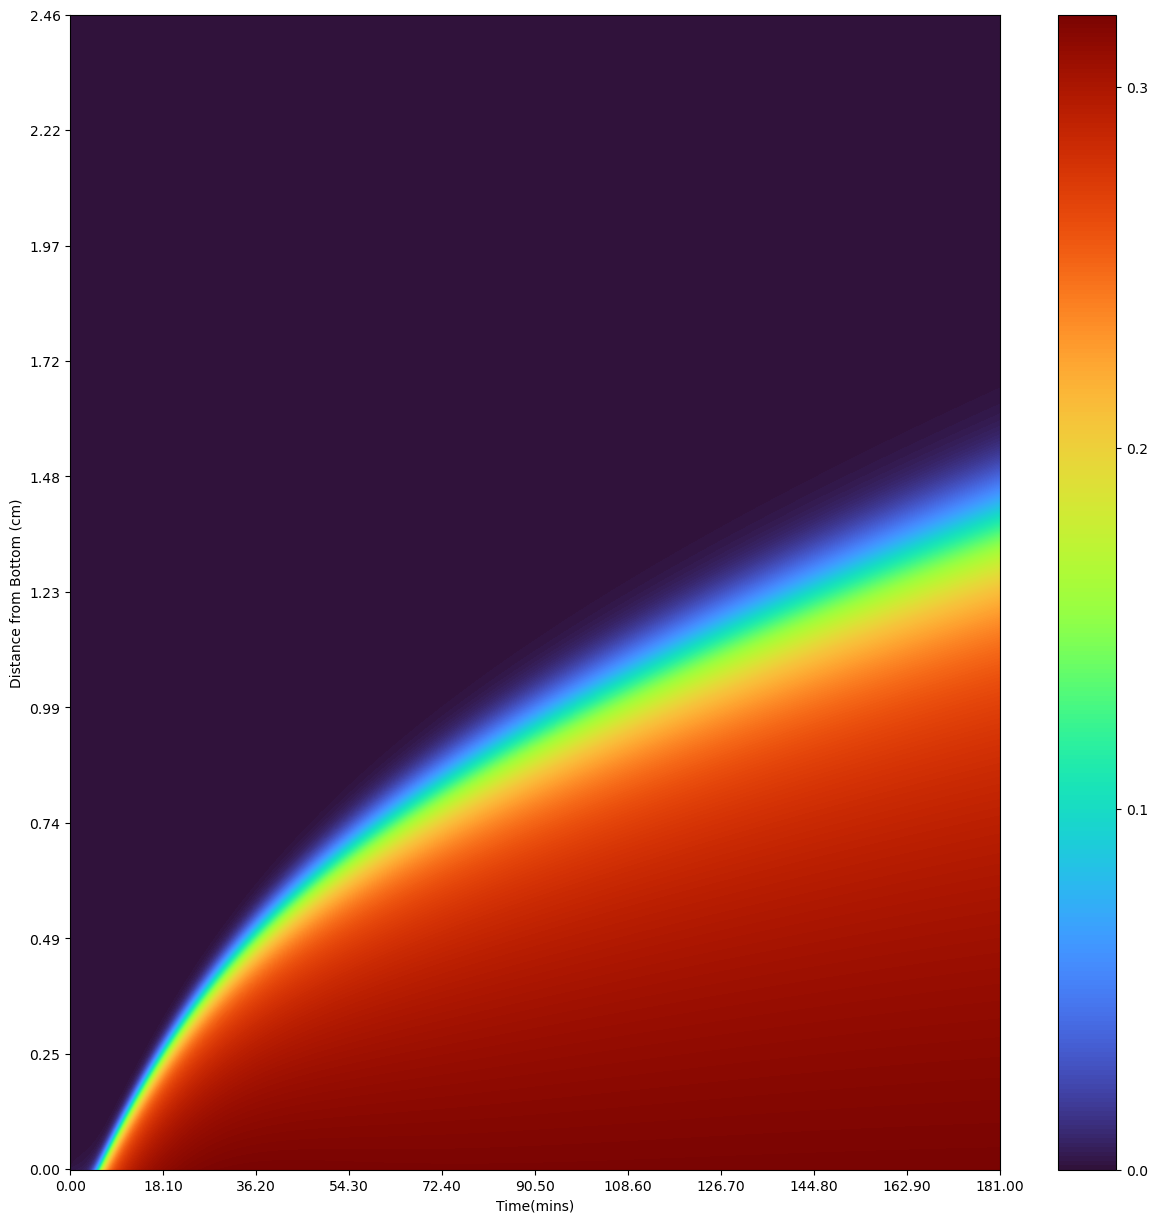

In [6]:
# Plot FDM results

T,X = np.meshgrid(t_FDM,x_FDM)
S_dat = S_array.T.reshape(-1,1)
X_dat = X.reshape(-1,1)
T_dat = T.reshape(-1,1)
data_size = X_dat.shape[0]
mass_data = np.mean(S_array.T,axis=0)
print(mass_data.shape)


time_array = np.arange(0,Nt)*dt
time_array.reshape(-1,1)
header_array = np.arange(0,Nx)*dx

plt.figure(figsize=(15, 15))
plt.imshow(S_array.T, cmap="turbo", aspect='auto', interpolation="bilinear")
# Create tick positions
t_tick_positions = np.linspace(0, Nt, 11)
x_tick_positions = np.linspace(0, Nx, 11)

# Create labels with two decimal places
t_labels = [f"{label:.2f}" for label in np.linspace(0, total_time, 11)]
x_labels = [f"{label:.2f}" for label in np.linspace(0, sample_length, 11)]

# Apply formatted labels to the plot
plt.xticks(ticks=t_tick_positions, labels=t_labels)
plt.yticks(ticks=x_tick_positions, labels=x_labels)
plt.xlabel('Time(mins)')
plt.gca().invert_yaxis()
plt.ylabel('Distance from Bottom (cm)')
plt.colorbar(ticks = np.arange(-1, 1.1, .1))
#plt.xlim(0,25000)
#plt.savefig(save_path + 'FDM_forward_10hrs.png')
plt.show()


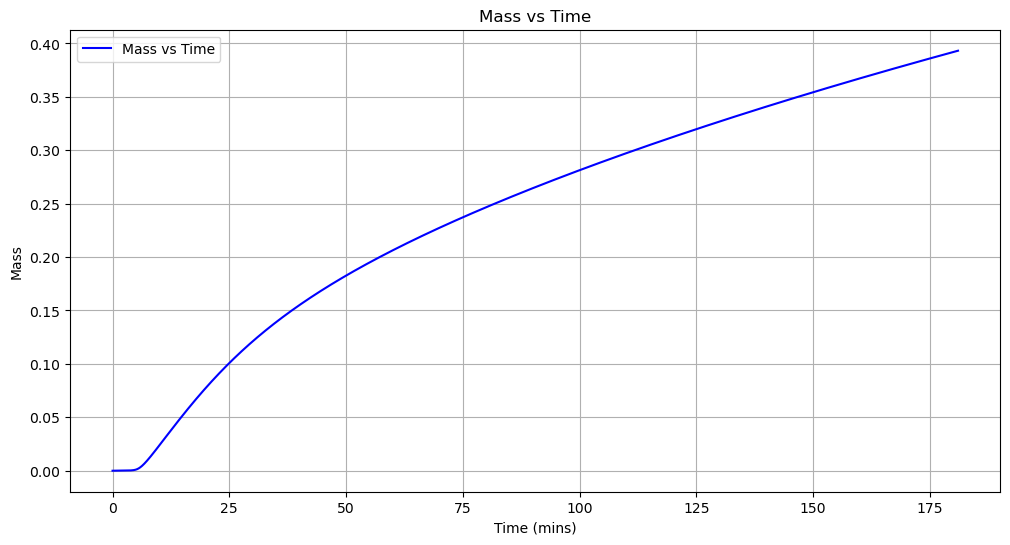

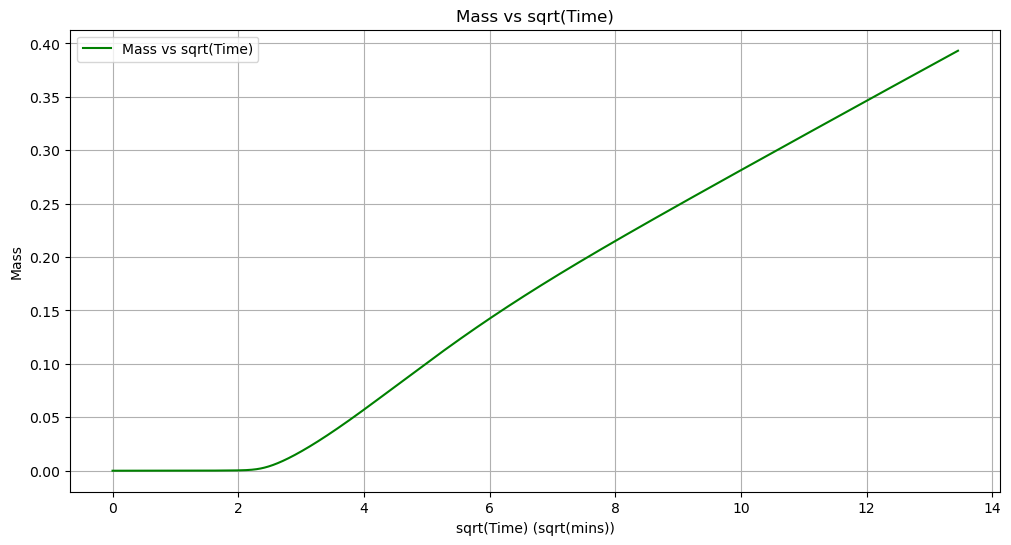

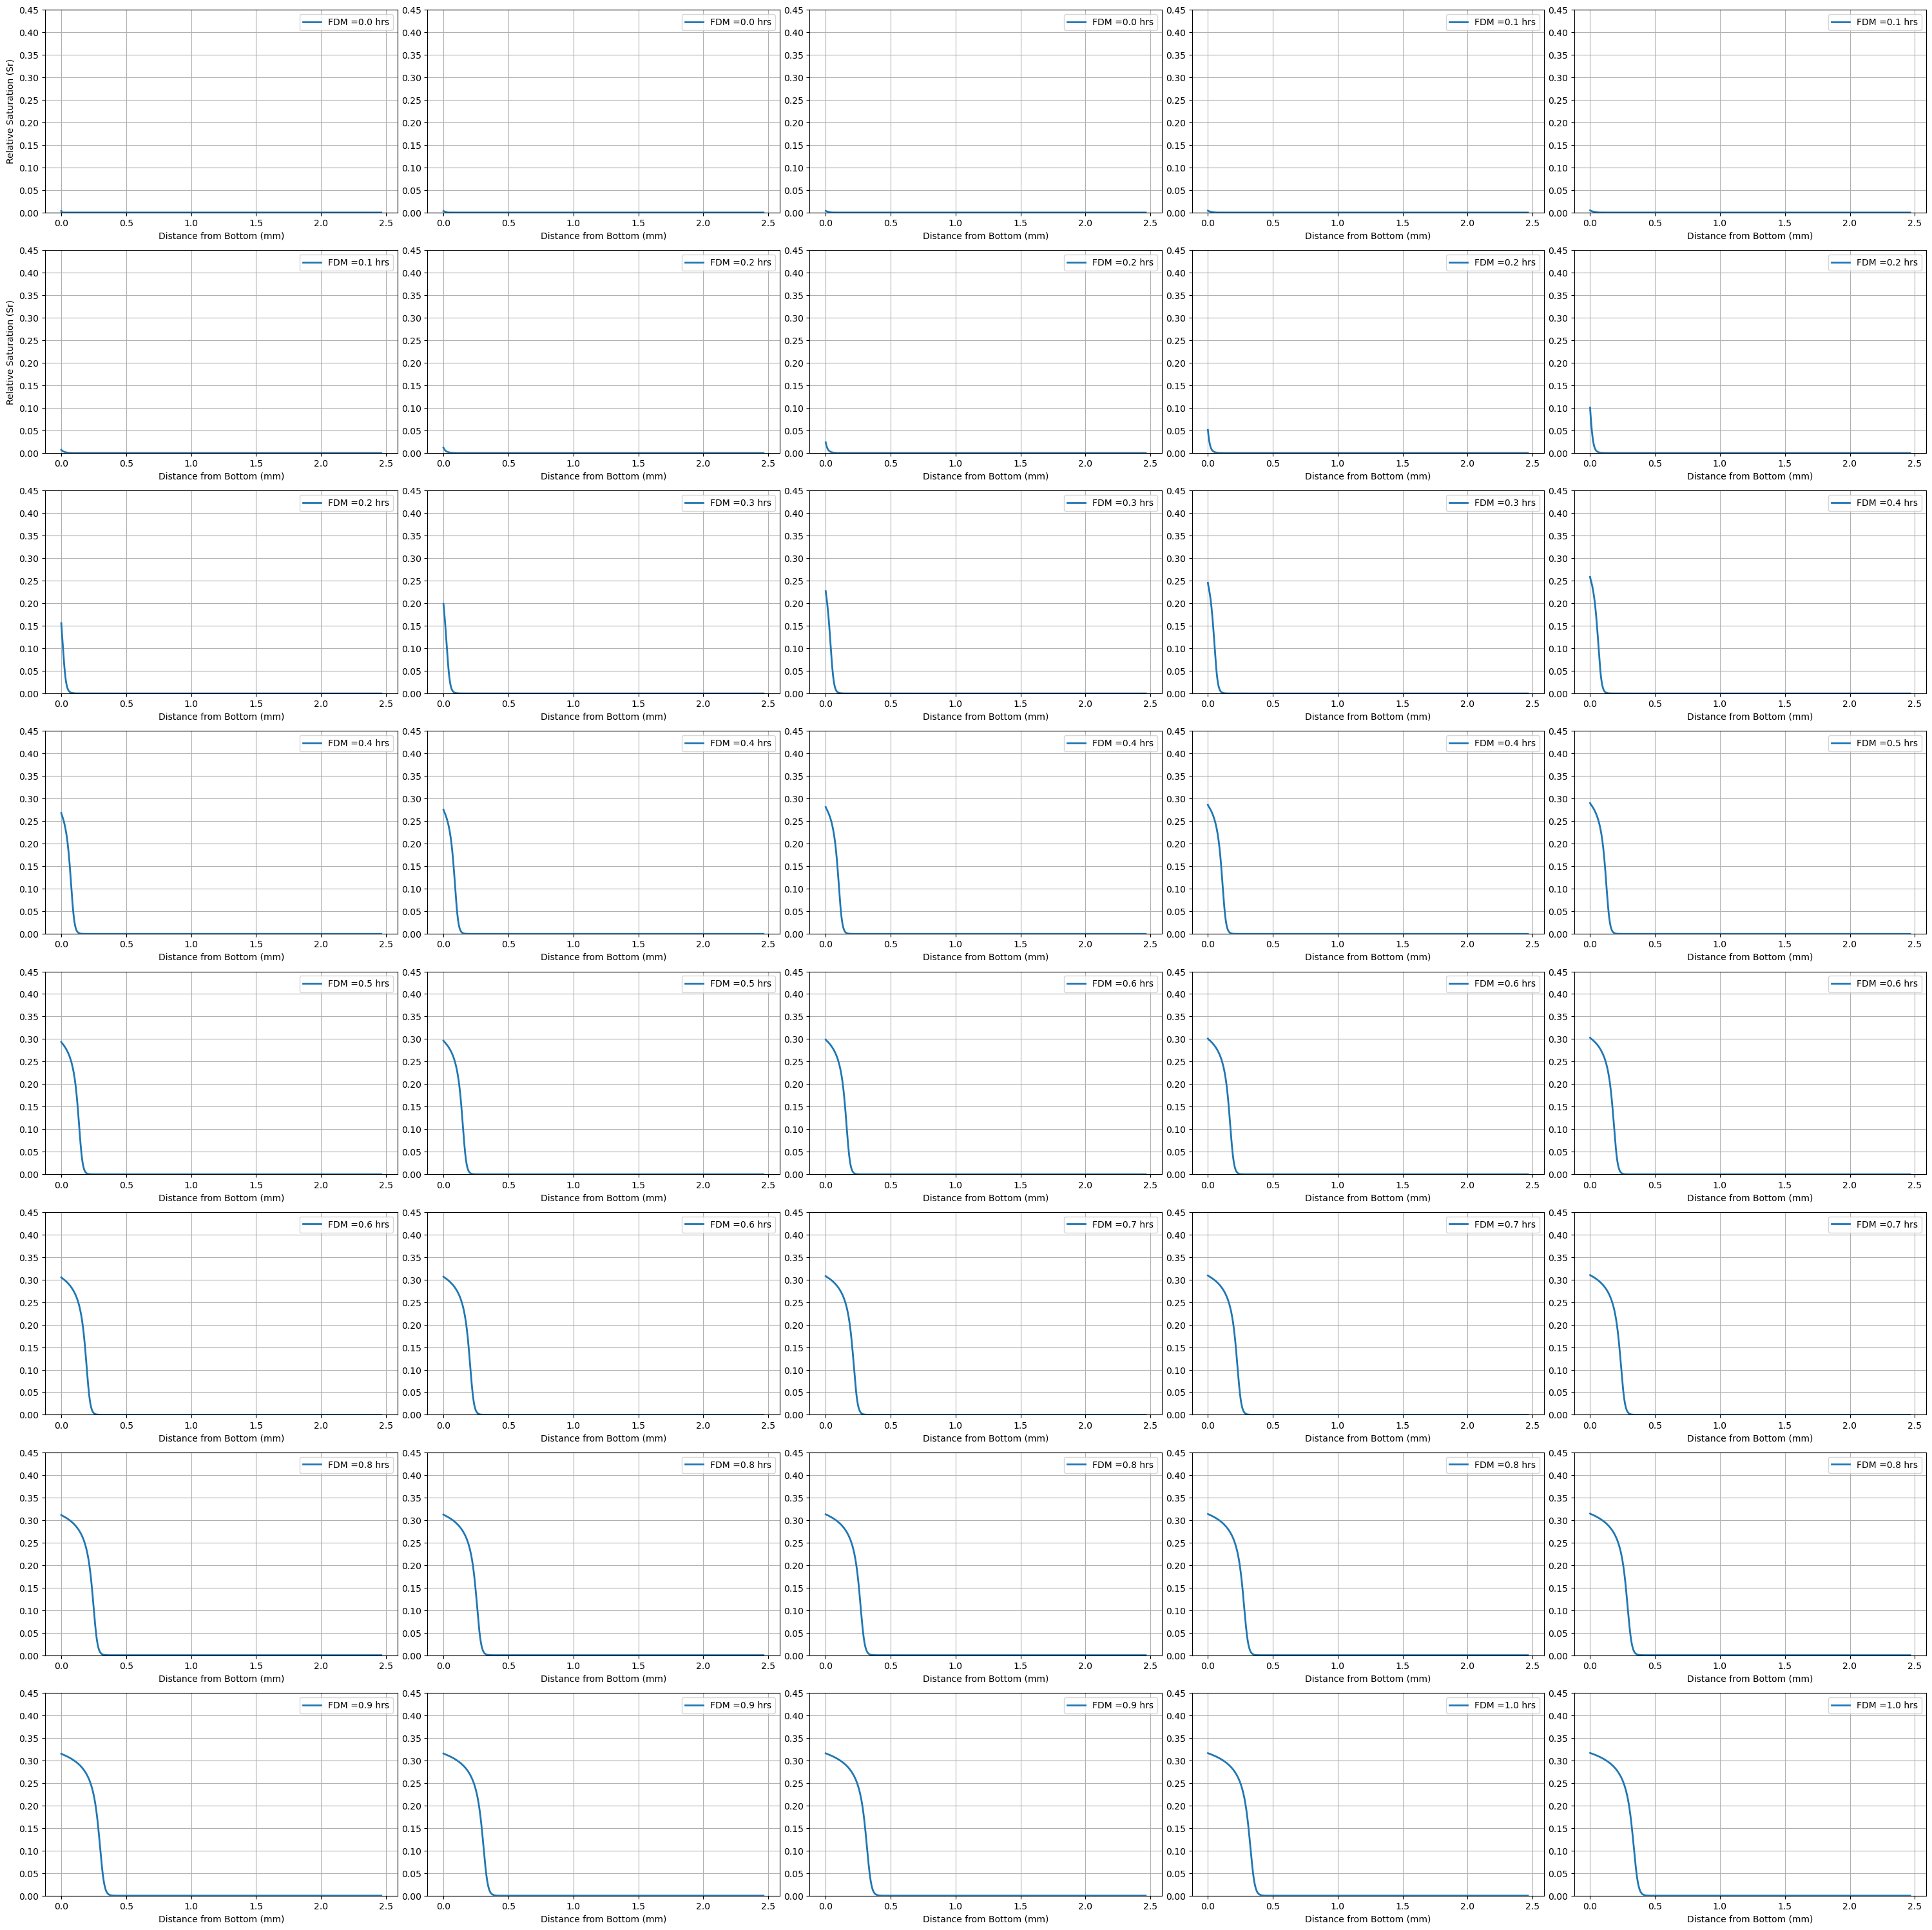

In [7]:
# S_array is the saturation array of shape (Nt, Nx)
# Time array
time_array = np.arange(0, Nt) * dt  # Nt: Number of time steps, dt: Time step size

# Spatial header array
header_array = np.arange(0, Nx) * dx  # Nx: Number of spatial points, dx: Spatial resolution

# Calculate the mass at each time step 
# Use the trapezoidal rule to approximate the integral
mass_array = np.trapz(S_array, header_array, axis=1)  # Integral along spatial axis

# Create the square root of time array
sqrt_time_array = np.sqrt(time_array)

# Plot Mass vs Time
plt.figure(figsize=(12, 6))
plt.plot(time_array, mass_array, label="Mass vs Time", color='blue')
plt.xlabel("Time (mins)")
plt.ylabel("Mass")
plt.title("Mass vs Time")
plt.grid()
plt.legend()
plt.show()

# Plot Mass vs sqrt(Time)
plt.figure(figsize=(12, 6))
plt.plot(sqrt_time_array, mass_array, label="Mass vs sqrt(Time)", color='green')
plt.xlabel("sqrt(Time) (sqrt(mins))")
plt.ylabel("Mass")
plt.title("Mass vs sqrt(Time)")
plt.grid()
plt.legend()
plt.show()


fig, ax = plt.subplots(8, 5, figsize=(30, 30))

row = 0
column = 0
for count in np.arange(0,40): 
    # Plotting the result
    if count==0:
        ax[row, column].plot(x_FDM, S_array[(count*250), :], linewidth=2, label=f'FDM ={count*250*0.0001} hrs')
     
    else:
        ax[row, column].plot(x_FDM, S_array[(count*250)-1, :], linewidth=2, label=f'FDM ={round(count*250*0.0001,1)} hrs')
  
    ax[row, column].set_xlabel('Distance from Bottom (mm)')
    ax[0, 0].set_ylabel('Relative Saturation (Sr)')
    ax[1, 0].set_ylabel('Relative Saturation (Sr)')
    ax[row, column].set_ylim([0, 0.45])
    ax[row, column].legend(loc='upper right')
    ax[row, column].grid(True)
    if (count + 1) % 5 == 0:  
        row += 1
        column = 0
    else:
        column += 1  

plt.tight_layout()
plt.show()